# importing libaraies


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


load dataset

In [5]:
df= pd.read_csv(r"c:\Users\abdul\Downloads\archive (4)\car_prediction_data.csv")

In [6]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
df.isnull().sum()



Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [11]:
y = df['Present_Price']  # Target variable
X = df.drop('Present_Price', axis=1)

In [12]:
# Create synthetic target for learning
np.random.seed(42)
df['Price'] = df['Present_Price'] * np.random.uniform(0.8, 1.2, size=len(df))

y = df['Price']
X = df.drop('Price', axis=1)


In [13]:
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']
numerical_features = ['Year', 'Present_Price', 'Kms_Driven', 'Owner']

In [14]:
numeric_transformer = StandardScaler()

In [15]:
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Train Model (Random Forest)

In [18]:

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train model
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred = model.predict(X_test)


In [20]:
y_pred

array([ 0.58130712, 14.8120111 , 10.25817512,  0.60240478, 15.55949581,
        9.56721172,  1.61941135,  0.87885317,  0.54353806,  9.51143757,
       10.12224443,  1.56354761, 10.51168537,  0.54068086,  9.23321933,
        4.62956196,  1.71172966, 16.91761967,  0.50465192,  1.6111122 ,
        0.72274742,  9.80432247, 10.23746726,  4.78062251,  1.02305229,
        6.49398507,  8.98732993,  5.3954661 ,  1.44357941,  1.48131077,
        0.77577431, 12.87599428,  0.93020415,  7.05717635,  9.68267463,
        7.19447744, 15.97963791, 17.81996183,  4.22755886, 16.08892511,
       13.03193305, 11.3675326 ,  6.50138747,  0.75814235,  9.92443457,
        1.21101662, 14.0618358 , 23.86180457,  4.73505978,  6.33327145,
        9.36794503,  1.51616973, 34.25761848, 24.75282977, 10.06364443,
       14.37337968,  5.01798288, 10.31427642,  7.92448946,  8.95665652,
        0.62756997])

In [21]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


RMSE: 1.0164512820185758
R2 Score: 0.9778567648607912


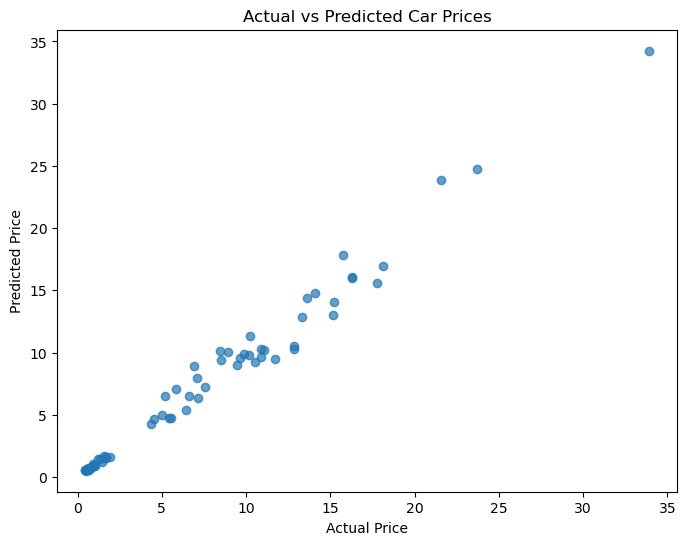

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()


                   Feature  Importance
1            Present_Price    0.978538
2               Kms_Driven    0.008235
0                     Year    0.007451
9   Transmission_Automatic    0.002189
5         Fuel_Type_Diesel    0.000958
6         Fuel_Type_Petrol    0.000715
7       Seller_Type_Dealer    0.000707
10     Transmission_Manual    0.000521
8   Seller_Type_Individual    0.000456
3                    Owner    0.000209
4            Fuel_Type_CNG    0.000020


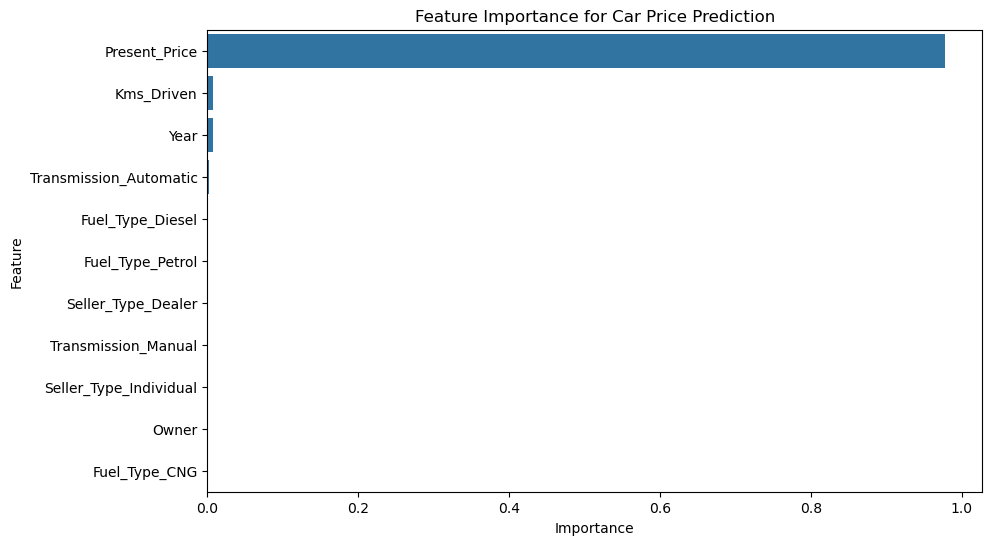

In [24]:

feature_names = numerical_features + list(
    model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
)


importances = model.named_steps['regressor'].feature_importances_


feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(feat_imp)


plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance for Car Price Prediction")
plt.show()


Absolutely! Here’s a **full Markdown description** of your Car Price Prediction project **without any code**, purely theoretical and explanatory:

---

# **Car Price Prediction Using Machine Learning**

This project demonstrates how to predict car prices using machine learning. It covers the entire workflow: **data collection, preprocessing, feature engineering, model training, evaluation, and visualization**.

---

## **1. Project Overview**

The goal is to predict the price of a car based on features such as brand, mileage, year, engine size, fuel type, transmission, and ownership. This kind of prediction is widely used in **dealerships, resale markets, and online car valuation platforms**.

---

## **2. Data Collection**

The first step is to collect a dataset containing car attributes and their prices. Typical features include:

* **Numerical Features:** Year of manufacture, mileage, engine size, horsepower, etc.
* **Categorical Features:** Brand, model, fuel type, transmission, and seller type.
* **Target Variable:** The price of the car (or a synthetic price if not available).

The dataset can come from open-source datasets like Kaggle or government car databases.

---

## **3. Data Preprocessing**

Before training a machine learning model, the dataset must be cleaned and transformed:

* **Handling Missing Values:** Remove or impute missing entries to prevent errors.
* **Encoding Categorical Variables:** Convert text-based features like fuel type or brand into numerical form using techniques such as one-hot encoding.
* **Scaling Numerical Features:** Standardize numerical features to a uniform scale so that models perform better.
* **Synthetic Target (Optional):** If the dataset doesn’t include a price column, a synthetic price can be generated based on related features.

---

## **4. Feature Engineering**

Feature engineering improves the predictive power of the model:

* Create new features or modify existing ones to better capture patterns (e.g., age of car = current year - year of manufacture).
* Select only the relevant features for prediction to reduce noise and improve performance.

---

## **5. Train-Test Split**

The dataset is split into **training** and **testing** subsets:

* **Training Set:** Used to teach the machine learning model how features relate to car price.
* **Testing Set:** Used to evaluate how well the model generalizes to unseen data.

Typically, 70–80% of data is used for training, and the remainder is used for testing.

---

## **6. Model Selection**

Regression models are chosen because the target variable (price) is continuous:

* **Linear Regression:** Simple and interpretable, good for baseline predictions.
* **Random Forest Regressor:** Handles nonlinear relationships and interactions between features; often more accurate.
* Other models can include Gradient Boosting, XGBoost, or Neural Networks for advanced performance.

---

## **7. Model Training**

The model learns the relationship between car features and their prices by minimizing prediction errors on the training set. This involves iteratively adjusting model parameters to fit the data.

---

## **8. Model Evaluation**

After training, the model is evaluated on the test set:

* **Root Mean Squared Error (RMSE):** Measures the average prediction error in price units.
* **R² Score:** Indicates the proportion of variance in price explained by the features; closer to 1 is better.

Good evaluation ensures that the model can **accurately predict prices for new cars**.

---

## **9. Prediction Visualization**

Visualizing predicted vs actual prices helps to understand model performance:

* Scatter plots of actual vs predicted prices can reveal trends, outliers, and model accuracy.
* Feature importance plots show which car attributes most influence price predictions.

---

## **10. Real-World Applications**

* **Used Car Market:** Predict fair resale prices.
* **Dealerships:** Help set competitive pricing strategies.
* **Online Platforms:** Assist customers in evaluating the value of their vehicles.
* **Insurance & Loans:** Aid in determining insurance premiums or loan eligibility based on car value.

---


